# Blue Whale Heart Rates

By how much do blue whale heart rates change when they dive down to find food?

The file `blue-whale-heart-rates.csv` contains heart rate data (measured in beats per minute) for blue whales. The data captures the dynamics of their heart rates as they dive over one hundred meters deep to forage for food. The heart rate measurements are taken approximately every 10 seconds during 8 separate dives.

### Dive Phases
The data records the heart rates corresponding to different dive states:
1. Descent: The whale begins its dive, descending into the depths.
2. Lunging: The whale opens its mouth and lunges upward, engulfing prey and water.
3. Filtering: After lunging, the whale sinks slightly and filters out water to retain food.
4. Ascent: The whale returns to the surface to breathe, marking the end of a dive.
5.  Surface: The blue whale is now on the surface (upper 5 meters)

The lunging and filtering process may occur multiple times on a single dive. The next dive cycle begins with another descent.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/catalin5433/whale-heart-rates/refs/heads/main/blue-whale-heart-rates.csv')
df.head()

,timestamp,heart_rate,dive_id,dive_phase
0,8/27/18 17:10:10,NaN,2,descent
1,8/27/18 17:10:22,5.24,2,descent
2,8/27/18 17:10:31,6.55,2,descent
3,8/27/18 17:10:40,NaN,2,descent
4,8/27/18 17:10:48,NaN,2,descent


### Project Ideas

#### Warmup
Calculate the average heart rates for each dive phase.

#### Challenge
Investigate the relationship between dive duration and the maximum heart rate at the surface following the dive.

1. Data Preparation:
	- Convert the `timestamp` column to datetime format.

2. Calculate Dive Duration:
	- For each `dive_id`, identify the earliest timestamp for the descent phase.
	- For each `dive_id`, find the latest timestamp for the ascent phase.
	- Compute the `dive_duration` by subtracting the start of the descent from the end of the ascent, then convert this duration to minutes (`dt.total_seconds() / 60`).
	- Store the results in a new dataframe with 2 columns: `dive_id` and `dive_duration`.

3. Determine Maximum Surface Heart Rate:
	- Identify the maximum heart rate recorded at the surface after each dive.
	- Store the results in a new dataframe with 2 columns: `dive_id` and `max_surface_heart_rate`

4. Merge DataFrames:
	- Merge the dive duration and max surface heart rate dataframes.

5.	Visualize the Data:
	- Generate a scatter plot with dive duration on the x-axis and maximum surface heart rate on the y-axis to illustrate their relationship.

In [2]:
# 1. Data Preparation

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%m/%d/%y %H:%M:%S')

# Verify the conversion and check data types
print(df.dtypes)
df.head()

timestamp     datetime64[ns]
heart_rate           float64
dive_id                int64
dive_phase            object
dtype: object


,timestamp,heart_rate,dive_id,dive_phase
0,2018-08-27 17:10:10,NaN,2,descent
1,2018-08-27 17:10:22,5.24,2,descent
2,2018-08-27 17:10:31,6.55,2,descent
3,2018-08-27 17:10:40,NaN,2,descent
4,2018-08-27 17:10:48,NaN,2,descent


In [3]:
# 2. Calculate Dive Duration

# Filter for descent starts and ascent ends
descent_starts = df[df['dive_phase'] == 'descent'].groupby('dive_id')['timestamp'].min().reset_index(name='start_time')
ascent_ends = df[df['dive_phase'] == 'ascent'].groupby('dive_id')['timestamp'].max().reset_index(name='end_time')

In [4]:
# Merge these to calculate duration
dive_duration_df = pd.merge(descent_starts, ascent_ends, on='dive_id')
dive_duration_df.head()

,dive_id,start_time,end_time
0,2,2018-08-27 17:10:10,2018-08-27 17:22:36
1,3,2018-08-27 17:25:28,2018-08-27 17:37:52
2,4,2018-08-27 17:40:46,2018-08-27 17:49:46
3,5,2018-08-27 17:52:09,2018-08-27 18:01:46
4,7,2018-08-27 18:11:43,2018-08-27 18:22:56


In [5]:
# Compute duration in minutes
dive_duration_df['dive_duration'] = (dive_duration_df['end_time'] - dive_duration_df['start_time']).dt.total_seconds() / 60

# Keep only the requested columns
dive_duration_df = dive_duration_df[['dive_id', 'dive_duration']]

dive_duration_df.head()

,dive_id,dive_duration
0,2,12.433333
1,3,12.400000
2,4,9.000000
3,5,9.616667
4,7,11.216667


In [6]:
# 3. Determine Maximum Surface Heart Rate

# Identify the maximum heart rate recorded at the surface for each dive_id
max_surface_hr_df = df[df['dive_phase'] == 'surface'].groupby('dive_id')['heart_rate'].max().reset_index(name='max_surface_heart_rate')

# Display the results
max_surface_hr_df

,dive_id,max_surface_heart_rate
0,2,35.50
1,3,35.29
2,4,34.48
3,5,33.90
4,7,33.52
5,10,35.29
6,11,38.22
7,13,34.88


In [7]:
# 4. Merge DataFrames

# Merge the dive duration and max surface heart rate dataframes
merged_df = pd.merge(dive_duration_df, max_surface_hr_df, on='dive_id')

# Display the merged results
merged_df

,dive_id,dive_duration,max_surface_heart_rate
0,2,12.433333,35.50
1,3,12.400000,35.29
2,4,9.000000,34.48
3,5,9.616667,33.90
4,7,11.216667,33.52
5,10,11.016667,35.29
6,11,16.400000,38.22
7,13,10.916667,34.88


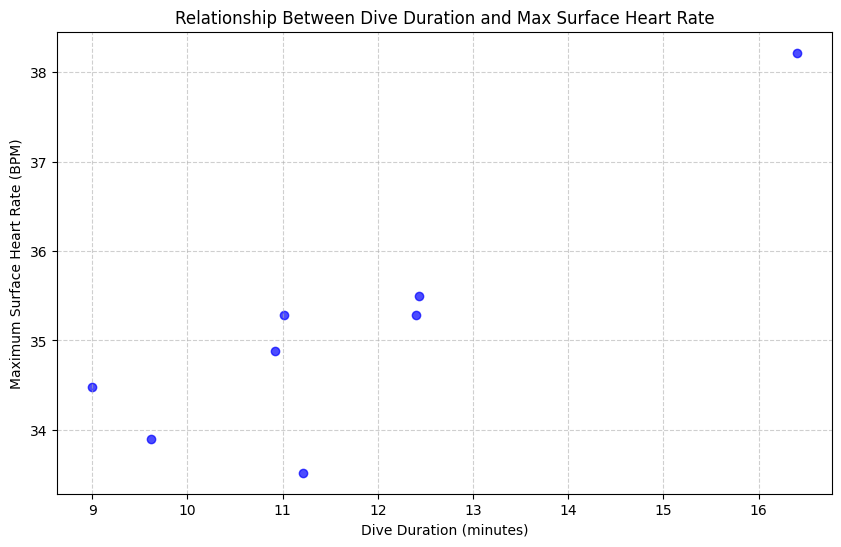

In [8]:
# 5. Visualize the Data

# Generate a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['dive_duration'], merged_df['max_surface_heart_rate'], color='blue', alpha=0.7)

# Add labels and title
plt.xlabel('Dive Duration (minutes)')
plt.ylabel('Maximum Surface Heart Rate (BPM)')
plt.title('Relationship Between Dive Duration and Max Surface Heart Rate')
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()